In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,roc_auc_score

In [ ]:
df=pd.read_csv('/content/smart_city_traffic_incident_decision_tree (1).csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IncidentID      3000 non-null   object 
 1   Hour            3000 non-null   int64  
 2   Weather         3000 non-null   object 
 3   RoadType        3000 non-null   object 
 4   TrafficDensity  3000 non-null   int64  
 5   VisibilityKm    3000 non-null   float64
 6   AverageSpeed    3000 non-null   int64  
 7   VehicleCount    3000 non-null   int64  
 8   Weekend         3000 non-null   object 
 9   RoadCondition   3000 non-null   object 
 10  Incident        3000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 257.9+ KB


In [ ]:
df.head()

,IncidentID,Hour,Weather,RoadType,TrafficDensity,VisibilityKm,AverageSpeed,VehicleCount,Weekend,RoadCondition,Incident
0,TRF-00001,20,Clear,Residential,17,8.7,77,527,Yes,Fair,No Incident
1,TRF-00002,4,Rain,Urban,63,11.5,82,607,No,Good,No Incident
2,TRF-00003,0,Clear,Urban,63,14.2,36,220,No,Good,No Incident
3,TRF-00004,15,Fog,Residential,55,10.8,96,253,No,Fair,No Incident
4,TRF-00005,8,Fog,Residential,27,12.6,22,155,No,Good,Incident


In [ ]:
df.shape

(3000, 11)

In [ ]:
df.describe()


,Hour,TrafficDensity,VisibilityKm,AverageSpeed,VehicleCount
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11.622667,49.871333,8.074767,59.826667,525.702333
std,6.936353,28.753998,4.045862,23.542062,273.739635
min,0.000000,1.000000,1.000000,20.000000,50.000000
25%,6.000000,25.000000,4.600000,39.000000,293.000000
50%,12.000000,50.000000,8.000000,60.000000,524.000000
75%,18.000000,75.000000,11.600000,80.000000,763.250000
max,23.000000,100.000000,15.000000,100.000000,1000.000000


In [ ]:
#indentifgy duplicate records
print("number of duplicates recodrs :",df.duplicated().sum())

number of duplicates recodrs : 0


In [ ]:
#indentifuy null values
df.isnull().sum()

,0
IncidentID,0
Hour,0
Weather,0
RoadType,0
TrafficDensity,0
VisibilityKm,0
AverageSpeed,0
VehicleCount,0
Weekend,0
RoadCondition,0


In [ ]:
#features summary
numerical_features=df.select_dtypes(include=['int64','float64']).columns
categorical_features=df.select_dtypes(include=['object']).columns
print("features summary")
print("numerical features:")
for col in numerical_features:
  print("-",col)


print("categorical features:")
for col in categorical_features:
  print("-",col)

features summary
numerical features:
- Hour
- TrafficDensity
- VisibilityKm
- AverageSpeed
- VehicleCount
categorical features:
- IncidentID
- Weather
- RoadType
- Weekend
- RoadCondition
- Incident


In [ ]:
from sklearn.preprocessing import LabelEncoder
df.columns = df.columns.str.strip()
le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])
df['RoadType'] = le.fit_transform(df['RoadType'])
df['Weekend'] = le.fit_transform(df['Weekend'])
df['RoadCondition'] = le.fit_transform(df['RoadCondition'])

In [ ]:
# Target column encoding
df['Incident'] = le.fit_transform(df['Incident'])

# 'Incident': 1
# 'No Incident': 0

In [ ]:
df = df.drop('IncidentID', axis=1)
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
print(x_train.columns)

Index(['Hour', 'Weather', 'RoadType', 'TrafficDensity', 'VisibilityKm',
       'AverageSpeed', 'VehicleCount', 'Weekend', 'RoadCondition'],
      dtype='object')


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# model building
model = DecisionTreeClassifier(criterion='entropy')
model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
#predictions on test data
y_pred=model.predict(x_test)

In [ ]:
#evaluation metrics
accuracy=accuracy_score(y_test,y_pred)
conf_matrix=confusion_matrix(y_test,y_pred)
class_report=classification_report(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_pred)
print("accuracy:",accuracy)
print("confusion matrix:")
print(conf_matrix)
print("classification report:")
print(class_report)
print("roc_auc_score:",roc_auc)

accuracy: 0.7216666666666667
confusion matrix:
[[124  78]
 [ 89 309]]
classification report:
              precision    recall  f1-score   support

           0       0.58      0.61      0.60       202
           1       0.80      0.78      0.79       398

    accuracy                           0.72       600
   macro avg       0.69      0.70      0.69       600
weighted avg       0.73      0.72      0.72       600

roc_auc_score: 0.6951216478431763


In [ ]:
#training Accuracy
y_train_pred=model.predict(x_train)
train_accuracy=accuracy_score(y_train,y_train_pred)
print("training accuracy:",train_accuracy)
#testing Accuracy
y_test_pred=model.predict(x_test)
test_accuracy=accuracy_score(y_test,y_test_pred)
print("testing accuracy:",test_accuracy)

training accuracy: 1.0
testing accuracy: 0.7216666666666667


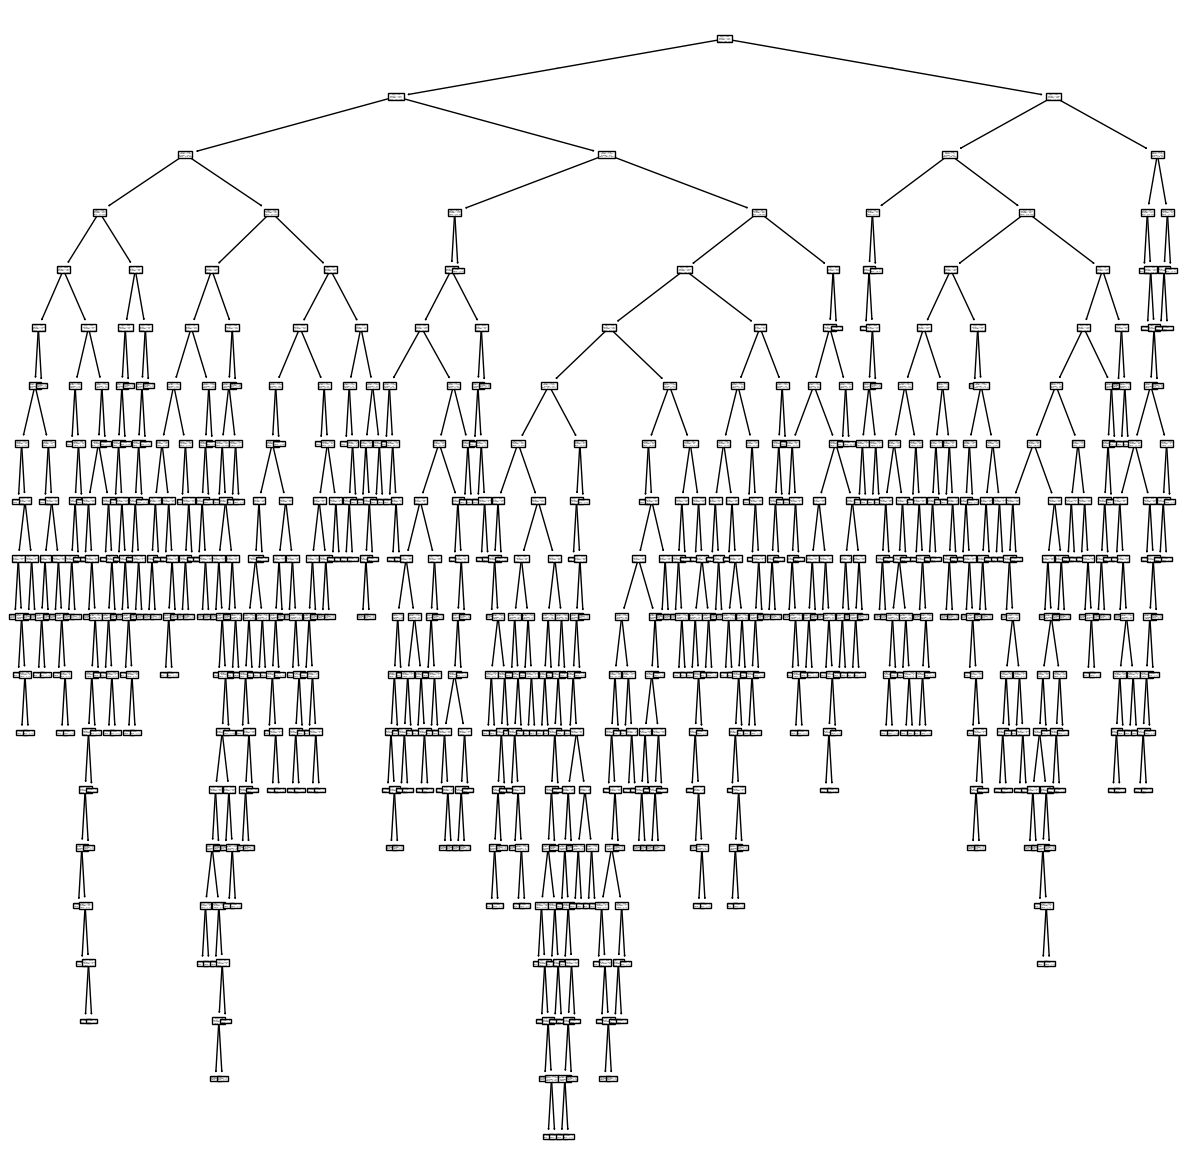

In [ ]:
#display decision Tree
y_test_pred=model.predict(x_test)
import matplotlib.pyplot as plot
from sklearn.tree import plot_tree
plot.figure(figsize=(15,15))
plot_tree(model)
plot.show()

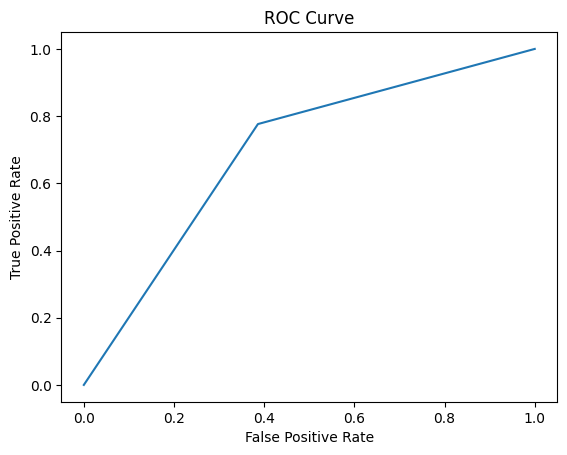

In [ ]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()